# Видео 2

Проверим гипотезу: возможно ли попасть в цель, стреляя навесом из винтовки Мосина. И если да, то какие ограничения существуют.

То есть, рассматривая пулю как материальную точку и учитывая её вес и силу сопротивления ветра, нужно решить следующие задачи:
- Найти $\alpha$ (начальный угол навеса), который необходим для попадания в цель. Вывести значение в градусах.
- Определить, какой максимальной высоты при этом угле достигнет пуля. Вывести значение.
- Построить график $y(x)$, $F_c(t)$.


Необходимо решить задачу двумя способами: когда учитывается и не учитывается сопротивление воздуха и когда $F_c(v^2)=-kv \vec{v}$. Вторая задача может быть решена только с помощью численного интегрирования.

Так как мы проверяем винтовку Мосина, то все технические характеристики, такие как вес пули $m$, скорость пули на вылете $v_0$, эффективное расстояние для стрельбы, взяты из официальной документации.

$m=13,6\ г, L=1500\ м, k=1,3 \cdot 10^{-5}, v_0=870\ м/с$.

Eq(x(t), 870.0*t*cos(alpha))
Eq(y(t), -4.9*t**2 + 870.0*t*sin(alpha))
время до цели на расстонии 1500: [{t: 1.72413793103448/cos(alpha)}]
углы в радианах: [-3.13188138111850, -1.58050759926619, 0.00971127247129410, 1.56108505432360]
угол 1: 0.5564149263067328 угол 2: 89.44358507369327
скорость vy: -9.8*t + 870.0*sin(alpha)
максимальная высота 3.64184166337657 метра
-6.47438517933616e-6*x**2 + 0.00971157776900421*x


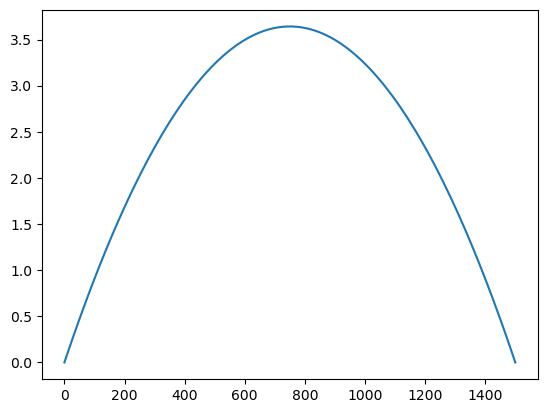

In [405]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t, l, ics= sp.symbols('t alpha x')
x = sp.Function('x')(t)
y = sp.Function('y')(t)
m = 13.6e-03
L = 1500
k = 1.3e-05
v0 = 870


#без учета силы сопротивления воздуха на пулю действует только сила притяжения
#на x она не проецируется
# m*ax = 0
# m*ay = -m*g
eqnx = sp.Eq(m*sp.Derivative(x, t, 2), 0)
eqny = sp.Eq(m*sp.Derivative(y, t, 2), -m*9.8)
# resx = sp.dsolve(eqnx, x(t), ics=({x(t).subs(t, 0):v0*sp.cos(l)}))
# resy = sp.dsolve(eqny, y(t), ics=({y(t).subs(t, 0):v0*sp.sin(l)}))

res = sp.dsolve([eqnx, eqny], [x, y], ics={x.diff(t).subs(t, 0):v0*sp.cos(l), y.diff(t).subs(t, 0):v0*sp.sin(l), x.subs(t,0):0, y.subs(t,0):0})
print(res[0])
print(res[1])
timeToTarget = sp.solve(res[0].subs(x, L))
print(f'время до цели на расстонии {L}: {timeToTarget}')
angel1 = sp.solve(res[1].subs(y, 0).subs(t, timeToTarget[0][t]))
print(f'углы в радианах: {angel1}')
print(f'угол 1: {np.degrees(float(angel1[2].evalf()))} угол 2: {np.degrees(float(angel1[3].evalf()))}')

#максимальная высота достигается при нулевой скорости по y
vy = sp.diff(res[1].rhs, t)
print(f'скорость vy: {vy}')
tmax = (sp.solve(vy, t))
tmax_val = tmax[0].subs(l, angel1[2].evalf())
h1 = (res[1].rhs).subs({t: tmax_val,l: angel1[2].evalf()})
print(f'максимальная высота {h1} метра')
#вывод функции y(x)
#выразим t через x
time = sp.solve(res[0].subs(x, ics))
time_val = time[0][t].subs(l, angel1[2].evalf())
y_x = res[1].rhs.subs({t: time_val, l: angel1[2].evalf()})
print(y_x)

tx = np.linspace(0,L, 100)

fig, ax = plt.subplots()
YX = sp.lambdify(ics, y_x, 'numpy')
ax.plot(tx, YX(tx), label='$y(x)$')
plt.show()


Отрицательные углы отметаем, получаем либо 0.55 градуса, либо 89,44. Оба угла граничат либо с выстрелом параллельно земле, либо перпендекулярно, свиду глупость...
при угле 89,44 высота пули зашкаливает, отбрасываем тоже как нереальный

начальный угол для попадания в цель с учётом сопротивления воздуха = 1.85938720703125 


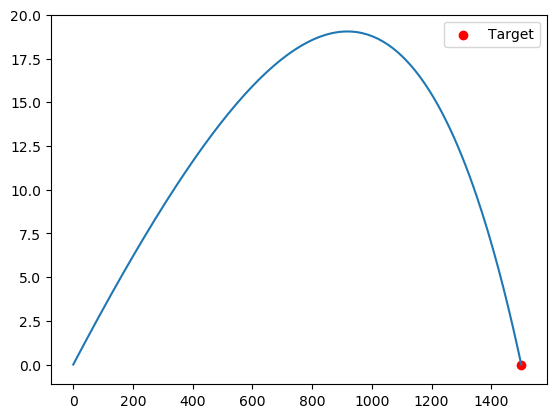

максимальная высота пули: 19.05243149562197


In [406]:

#с учётом силы сопротиления воздуха
# запишем уравнения проекции силы сопротивления воздуха
#Fc = -k*sqrt(vx**2 + vy**2)*(vx*i + vy*j)
# сила противодействует ускорению пули
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar


alpha_low, alpha_high = 0.1, 45.0

def model(t, u, m, k):
    [x, y, vx, vy] = u
    v = np.sqrt(vx**2 + vy**2)
    dxdt = vx
    dydt = vy
    dvxdt = -(k/m) * v * vx
    dvydt =  -9.81 - (k/m)*v*vy
    return [dxdt, dydt, dvxdt, dvydt]

def model_trajectory(alpha_deg, m, k, v0, max_time=100):
    alpha = np.radians(alpha_deg)
    func0 = [0,0,v0*np.cos(alpha), v0*np.sin(alpha)]
    
    def hit_ground(t, u, *args):
        return u[1]
    hit_ground.terminal=True
    hit_ground.direction = -1

    sol = solve_ivp(
        model,
        (0, max_time),
        func0,
        args=(m, k),
        events=hit_ground,
        method='RK45',
        dense_output=True
    )
    return sol

best_alpha = 0
for _ in range(100):
    alpha_mid = (alpha_low + alpha_high)/2
    sol = model_trajectory(alpha_mid, m, k, v0)

    if sol.y_events[0].size > 0:
        l_c = sol.y_events[0][0][0] 
        if abs(l_c - L) < 1:
            best_alpha = alpha_mid
            break
        elif l_c < L:
            alpha_low = alpha_mid
        else:
            alpha_high = alpha_mid

print(f'начальный угол для попадания в цель с учётом сопротивления воздуха = {best_alpha} ')

sol_v = model_trajectory(best_alpha, m, k, v0)
tv = np.linspace(0, sol_v.t_events[0][0], 150)
x, y, *_= sol_v.sol(tv)

fig, ax = plt.subplots()
ax.plot(x, y)
ax.scatter([L], [0], c='red', label='Target')
ax.legend()
plt.show()

def vy_zero(t):
    _, y, _, vy = sol_v.sol(t)
    return abs(vy)

t_max = minimize_scalar(vy_zero, bounds=(0, sol_v.t_events[0][0]), method='bounded').x
_, y_max, _, _ = sol_v.sol(t_max)
print(f'максимальная высота пули: {y_max}')

         

# Видео 3

## Задача 1

Груз $A$ весом $P$ спускается по боковой грани призмы $B$, расположенной под углом $\alpha$ к горизонту.

Призма движется по гладкой горизонтальной плоскости направо с ускорением $a$.

Определите $x(t)$ груза по отношению к призме и его давление на её боковую грань, если коэффициент трения скольжения груза о грань призмы равен $f$.

Решите аналитически.

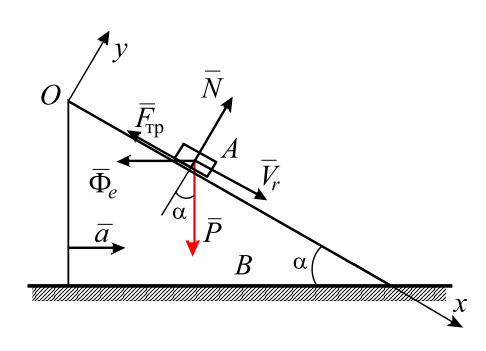

In [ ]:
t, P, m, f, a, Vrx = sp.symbols('t P m f a Vrx', real=True)
x = sp.Function('x')(t)
g = 9.81

N = m*(sp.cos(l) + sp.sin(l))#получено из уравнения движения по y, т.к. движения по y нет, уравнение можно приравнять в нулю
ma = m*g*sp.sin(l) - f*N - m*a*sp.cos(l).simplify()
eqnx = sp.Eq(m*sp.Derivative(x, t, 2), ma)
#примем начальные условия за нулевые
res = sp.dsolve(eqnx, x, ics={x.diff(t).subs(t, 0):0, x.subs(t,0):0}, hint='nth_linear_constant_coeff_undetermined_coefficients')
display(res)
display(f'давление груза на боковую панель: {N}')

Eq(x, t**2*(-0.5*a*cos(alpha) - 0.5*f*sin(alpha) - 0.5*f*cos(alpha) + 4.905*sin(alpha)))

'давление груза на боковую панель: m*(sin(alpha) + cos(alpha))'

# Видео 5

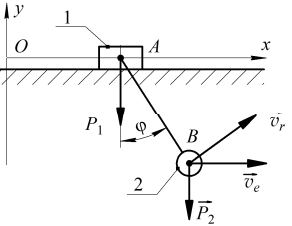

Найдите уравнение движения механизма (эллиптический маятник inverted pendulum on a cart) в общем виде, используя метод **Ньютона — Эйлера**. Известны массы $m_{1,2}$. Трение отсутствует. Тело $B$ рассматривайте как математический маятник.

Результат представьте в виде пары формул $(\ddot{\phi}, \ddot{x})$.


*Подсказка:*


``` python
from sympy.physics.mechanics import init_vprinting
init_vprinting()
```
Позволит выводить формулы в читаемом виде (не $\frac{dx}{dt}$, а $\dot{x}$). Также это позволит более успешно дифференцировать (но иногда необходимо результат обрабатывать `sp.simplify`, `sp.expand`).



In [495]:
from sympy.physics.vector import init_vprinting
from IPython.display import display, Math

init_vprinting(pretty_print=True)

t, m1, m2, l, g, T = sp.symbols('t m1 m2 l g T')
q = sp.Function('phi')(t)
x = sp.Function('x')(t)

 
eq_full = [sp.Eq(m2*l*sp.diff(q, t, 2), m2*sp.diff(x, t, 2)*sp.cos(q)-m2*g*sp.sin(q)),#тангенциальная составляющая движения маятника, учитывается влияение ускорения тележки при раскачивании от маятника
        sp.Eq(m2*l*sp.diff(q, t)**2, T - m2*g*sp.cos(q) + m2*sp.diff(x, t, 2)*sp.sin(q)),#центробежная часть движения маятника, учитывается ускорение тележки, из-за которого будет смещаться центр движения
        sp.Eq(m1*sp.diff(x, t, 2), T*sp.sin(q))#движение тележки зависит от натяжение
    ]
#поидее больше уравнений не нужно, т.к. связывает два тела нить и соотв сила натяжения
xxx = sp.solve(eq_full,[sp.diff(x,t,2),sp.diff(q,t,2), T])
qText = f"{sp.latex(sp.diff(q,t,2))} = {sp.latex(xxx[sp.diff(q,t,2)].simplify())}"
xText = f"{sp.latex(sp.diff(x,t,2))} = {sp.latex(xxx[sp.diff(x,t,2)].simplify())}"
display(Math(qText))
display(Math(xText))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Видео 6

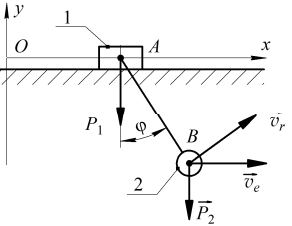

Найдите уравнение движения механизма (эллиптический маятник inverted pendulum on a cart) в общем виде, используя метод **Эйлера — Лагранжа**.

Сравните результат с заданием из прошлого видео.

Известны массы $m_{1,2}$. Трение отсутствует. Тело $B$ рассматривайте как математический маятник.

Результат представьте в виде пары формул $(\ddot{\phi}, \ddot{x})$.


*Подсказка:*


``` python
from sympy.physics.mechanics import init_vprinting
init_vprinting()
```
Позволит выводить формулы в читаемом виде (не $\frac{dx}{dt}$, а $\dot{x}$). Также это позволит более успешно дифференцировать (но иногда необходимо результат обрабатывать `sp.simplify`, `sp.expand`).



In [496]:
#за обобщенные координаты примем x - положение тележки и угол phi
#выведем координаты центра масс маятника:
l, t, m1, m2 = sp.symbols('l t m1 m2')
x = sp.Function('x')(t)
phi = sp.Function('phi')(t)
yBcm = l*sp.cos(phi)
xBcm = x + l*sp.sin(phi)

#найдем кинетическую энергию маятника: Т = 0.5*m*v**2
xxBcm = sp.diff(xBcm, t)
yyBcm = sp.diff(yBcm, t)
display(xxBcm)
display(yyBcm)
TB = (0.5*m2*(xxBcm**2 + yyBcm**2)).simplify()#кинетическая энергия маятника
TA = 0.5*m1*sp.diff(x)**2
display(TB)
display(TA)
T = (TA+TB).simplify()

#потенциальная энергия учитывается только для маятника, т.к. тележка стоит на поверхности
U = m2*g*l*sp.cos(phi)
L = T - U
display(L)#функция Лагранжа
#уравнения для координаты х
dLdx = sp.diff(L, x)
dLdxx = sp.diff(L, sp.diff(x))
dLdxxdt = sp.diff(dLdxx, t)
eqLx= sp.Eq(dLdxxdt - dLdx, 0).simplify()
display(eqLx)

#уравнение для координаты phi
dLdphi = sp.diff(L, phi)
dLdphiphi = sp.diff(L, sp.diff(phi))
dLdphiphidt = sp.diff(dLdphiphi, t)
eqLphi = sp.Eq(dLdphiphidt - dLdphi, 0).simplify()
display(eqLphi)
ddphi = sp.diff(phi, t, 2).simplify()
ddx = sp.diff(x, t, 2).simplify()
rez = sp.solve([eqLx, eqLphi], [ddx, ddphi])
phiText = f"{sp.latex(ddx)} = {sp.latex(rez[ddx].simplify())}"
xText = f"{sp.latex(ddphi)} = {sp.latex(rez[ddphi].simplify())}"
display(Math(xText))
display(Math(phiText))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

Как видно результаты совпадают.

Если честно, после решения методом Эйлера-Лагранжа, задался вопросом откуда появился  m2*sp.sin(phi)**2. Оказалось в методе Ньютона-Эйлера не учел ускорение тележки в уравнении для центробежной силы(для меня было не очевидно). В целом метод Эйлера-Лагранжа кажется проще, в нем меньше получится накосячить свиду